# Notebook 04 — EDA: Operational Data

**Mục tiêu**: Phân tích tình trạng vận hành
- **Shipments**: Tốc độ giao hàng, tỉ lệ giao đúng hạn
- **Returns**: Tỉ lệ trả hàng, lý do trả
- **Reviews**: Phân phối điểm đánh giá, sentiment
- **Inventory**: Tồn kho theo sản phẩm, tình trạng out-of-stock

**Tương ứng báo cáo**: Phần 2 — Chương 4.3 (Phân tích vận hành)

In [89]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_processed
from pathlib import Path

FIG_DIR = Path('../outputs/figures/eda')
sns.set_theme(style='whitegrid')
%matplotlib inline

In [101]:
shipments = load_processed('shipments_clean.csv')
returns   = load_processed('returns_clean.csv')
reviews   = load_processed('reviews_clean.csv')
inventory = load_processed('inventory_clean.csv')
orders    = load_processed('orders_clean.csv')
customers = load_processed('customers_clean.csv')
geography = load_processed('geography_clean.csv')

## 1. Vận chuyển (Shipments)

**Chỉ số cần phân tích**:
- On-time delivery rate (%)
- Thời gian giao hàng trung bình (ngày)
- Phân bổ theo carrier/đơn vị vận chuyển

Mean delivery_days: 4.50
Median delivery_days: 4
P90 delivery_days: 7
Mean order_to_delivery_days: 6.00


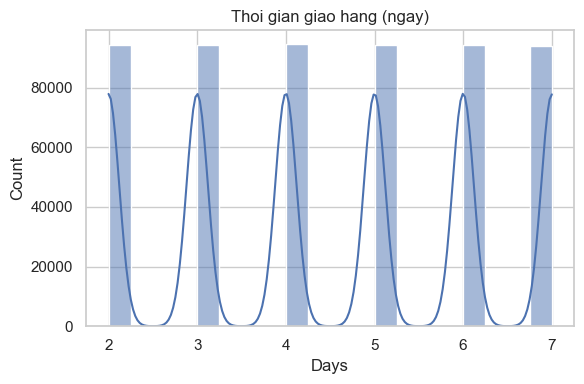

In [91]:
# 1) Thoi gian giao hang (ngay)
ship = shipments.copy()
ship['ship_date'] = pd.to_datetime(ship['ship_date'])
ship['delivery_date'] = pd.to_datetime(ship['delivery_date'])
ship['delivery_days'] = (ship['delivery_date'] - ship['ship_date']).dt.days

orders['order_date'] = pd.to_datetime(orders['order_date'])
ship = ship.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
ship['order_to_delivery_days'] = (ship['delivery_date'] - ship['order_date']).dt.days


print(f"Mean delivery_days: {ship['delivery_days'].mean():.2f}")
print(f"Median delivery_days: {ship['delivery_days'].median():.0f}")
print(f"P90 delivery_days: {ship['delivery_days'].quantile(0.9):.0f}")
print(f"Mean order_to_delivery_days: {ship['order_to_delivery_days'].mean():.2f}")

plt.figure(figsize=(6, 4))
sns.histplot(ship['delivery_days'], bins=20, kde=True)
plt.title('Thoi gian giao hang (ngay)')
plt.xlabel('Days')
plt.tight_layout()
plt.show()

**Nhận xét:** Đơn hàng trung bình mất khoảng 4.5 ngày để giao, đa số giao trong 4 ngày và 90% giao trong tối đa 7 ngày. => Không phải vấn đề về thời gian giao hàng, vì thời gian ship chỉ trong vòng 1 tuần.

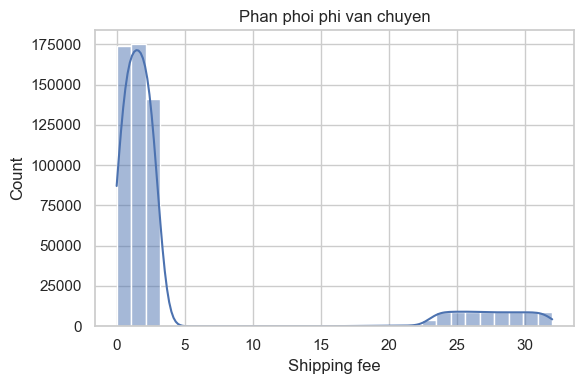

In [92]:
# 2) Phi van chuyen
plt.figure(figsize=(6, 4))
sns.histplot(ship['shipping_fee'], bins=30, kde=True)
plt.title('Phan phoi phi van chuyen')
plt.xlabel('Shipping fee')
plt.tight_layout()
plt.show()

**Nhận xét:** Phí vận chuyển trung vị 1.73, P90 = 25.09; đa số đơn phí thấp, một số ít đơn phí rất cao.

In [ ]:
# Merge ship với orders để lấy zip
ship = ship.merge(
    orders[['order_id', 'zip']],
    on='order_id',
    how='left'
)

# Geography tránh duplicate zip
geography = geography.drop_duplicates(subset='zip')

# Merge geography để lấy city
ship = ship.merge(
    geography[['zip', 'city']],
    on='zip',
    how='left'
)

# Tính median và P90
median_fee = ship['shipping_fee'].median()
p90_fee = ship['shipping_fee'].quantile(0.9)

print("Median:", median_fee)
print("P90:", p90_fee)

# Lọc đơn có phí ship từ median đến P90
high_ship = ship[
    (ship['shipping_fee'] >= median_fee) &
    (ship['shipping_fee'] <= p90_fee)
]

# Thống kê theo city
high_ship_city = (
    high_ship.groupby('city')
    .agg(
        total_orders=('order_id', 'count'),
        avg_shipping_fee=('shipping_fee', 'mean'),
        median_shipping_fee=('shipping_fee', 'median')
    )
    .sort_values('avg_shipping_fee', ascending=False)
)

display(high_ship_city.head(20))

Median: 1.73
P90: 25.09


,total_orders,avg_shipping_fee,median_shipping_fee
city,,,
Can Tho,3291,4.711990,2.47
Ben Tre,3848,4.610372,2.43
Da Lat,3354,4.568524,2.44
Bac Lieu,3929,4.553589,2.44
My Tho,3203,4.544920,2.44
Pleiku,4401,4.532318,2.44
Vung Tau,4155,4.487824,2.42
Ca Mau,3375,4.442012,2.42
Vinh Long,3786,4.437335,2.43


In [100]:
print(ship.columns)

Index(['order_id', 'ship_date', 'delivery_date', 'shipping_fee',
       'delivery_days', 'order_date', 'order_to_delivery_days', 'zip_x',
       'city_x', 'zip_y', 'zip', 'city_y', 'region', 'district'],
      dtype='object')


In [102]:
# Copy từ data gốc
ship = shipments.copy()

# Merge orders để lấy zip
ship = ship.merge(
    orders[['order_id', 'zip']],
    on='order_id',
    how='left'
)

# Geography tránh duplicate zip
geography = geography.drop_duplicates(subset='zip')

# Merge geography để lấy location
ship = ship.merge(
    geography[['zip', 'city', 'region', 'district']],
    on='zip',
    how='left'
)

# Tính median và P90
median_fee = ship['shipping_fee'].median()
p90_fee = ship['shipping_fee'].quantile(0.9)

print("Median:", median_fee)
print("P90:", p90_fee)

# Lọc đơn có phí ship từ median đến P90
high_ship = ship[
    (ship['shipping_fee'] >= median_fee) &
    (ship['shipping_fee'] <= p90_fee)
]

# Thống kê theo region + city
high_ship_city = (
    high_ship.groupby(['region', 'city'])
    .agg(
        total_orders=('order_id', 'count'),
        avg_shipping_fee=('shipping_fee', 'mean'),
        median_shipping_fee=('shipping_fee', 'median')
    )
    .sort_values('avg_shipping_fee', ascending=False)
)

display(high_ship_city.head(20))

Median: 1.73
P90: 25.09


total_orders  avg_shipping_fee  median_shipping_fee
region  city                                                                 
West    Can Tho                   3291          4.711990                 2.47
        Ben Tre                   3848          4.610372                 2.43
        Da Lat                    3354          4.568524                 2.44
        Bac Lieu                  3929          4.553589                 2.44
        My Tho                    3203          4.544920                 2.44
        Pleiku                    4401          4.532318                 2.44
        Vung Tau                  4155          4.487824                 2.42
        Ca Mau                    3375          4.442012                 2.42
        Vinh Long                 3786          4.437335                 2.43
        Ho Chi Minh City          4369          4.422758                 2.44
        Tra Vinh                  3518          4.398147                 2.44
        Rach Gia                  2999          4.374451                 2.43
        Soc Trang                 3548          4.295183                 2.43
        Buon Ma Thuot             3968          4.251056                 2.42
        Bien Hoa                  3027          4.237317                 2.42
East    Bac Ninh                  7318          4.199434                 2.43
Central Phan Thiet                5659          4.192138                 2.42
East    Thai Nguyen               7775          4.178003                 2.42
        Viet Tri                  7369          4.167552                 2.44
West    Long Xuyen                4012          4.163811                 2.42

In [111]:
# Lọc region = West
west_city = geography[geography['region'] == 'Central']

# Đếm số city unique
n_cities = west_city['city'].nunique()

print("Number of cities in West region:", n_cities)

# Xem danh sách city
display(sorted(west_city['city'].unique()))

Number of cities in West region: 12


['Da Nang',
 'Dong Hoi',
 'Hoi An',
 'Hue',
 'Kon Tum',
 'Nha Trang',
 'Phan Rang-Thap Cham',
 'Phan Thiet',
 'Quang Ngai',
 'Quy Nhon',
 'Tam Ky',
 'Tuy Hoa']

In [104]:
# Tính phí ship trung bình theo region
region_shipping = (
    ship.groupby('region')
    .agg(
        avg_shipping_fee=('shipping_fee', 'mean')
    )
    .sort_values('avg_shipping_fee', ascending=False)
)

display(region_shipping)

# Region có phí ship trung bình cao nhất
max_region = region_shipping['avg_shipping_fee'].idxmax()
max_value = region_shipping['avg_shipping_fee'].max()

# Region có phí ship trung bình thấp nhất
min_region = region_shipping['avg_shipping_fee'].idxmin()
min_value = region_shipping['avg_shipping_fee'].min()

print(f"Highest average shipping fee: {max_region} ({max_value:.2f})")
print(f"Lowest average shipping fee: {min_region} ({min_value:.2f})")

,avg_shipping_fee
region,
West,5.389595
East,4.827388
Central,4.790728


Highest average shipping fee: West (5.39)
Lowest average shipping fee: Central (4.79)


In [105]:
# Tổng phí ship theo region
region_shipping_total = (
    ship.groupby('region')
    .agg(
        total_shipping_fee=('shipping_fee', 'sum')
    )
    .sort_values('total_shipping_fee', ascending=False)
)

display(region_shipping_total)

# Region có tổng phí ship cao nhất
max_region = region_shipping_total['total_shipping_fee'].idxmax()
max_value = region_shipping_total['total_shipping_fee'].max()

# Region có tổng phí ship thấp nhất
min_region = region_shipping_total['total_shipping_fee'].idxmin()
min_value = region_shipping_total['total_shipping_fee'].min()

print(f"Highest total shipping fee: {max_region} ({max_value:.2f})")
print(f"Lowest total shipping fee: {min_region} ({min_value:.2f})")

,total_shipping_fee
region,
East,1244288.28
West,791855.41
Central,773165.97


Highest total shipping fee: East (1244288.28)
Lowest total shipping fee: Central (773165.97)


In [106]:
# Phí ship cao nhất và thấp nhất theo region
region_shipping_extreme = (
    ship.groupby('region')
    .agg(
        min_shipping_fee=('shipping_fee', 'min'),
        max_shipping_fee=('shipping_fee', 'max')
    )
)

display(region_shipping_extreme)

,min_shipping_fee,max_shipping_fee
region,,
Central,0.0,32.0
East,0.0,32.0
West,0.0,32.0


In [109]:
# ===== Shipping fee = 0 =====
ship_fee_0 = ship[
    ship['shipping_fee'] == 0
]

ship_fee_0_city = (
    ship_fee_0.groupby(['region', 'city', 'shipping_fee'])
    .agg(
        total_orders=('order_id', 'count')
    )
    .sort_values('total_orders', ascending=False)
)

print("=== SHIPPING FEE = 0 ===")
display(ship_fee_0_city)


# ===== Shipping fee = 32 =====
ship_fee_32 = ship[
    ship['shipping_fee'] == 32
]

ship_fee_32_city = (
    ship_fee_32.groupby(['region', 'city', 'shipping_fee'])
    .agg(
        total_orders=('order_id', 'count')
    )
    .sort_values('total_orders', ascending=False)
)

print("=== SHIPPING FEE = 32 ===")
display(ship_fee_32_city)

=== SHIPPING FEE = 0 ===


total_orders
region  city                shipping_fee              
East    Thai Nguyen         0.0                     35
        Ha Long             0.0                     34
        Cam Pha             0.0                     32
        Hanoi               0.0                     32
        Bac Ninh            0.0                     31
        Uong Bi             0.0                     30
Central Phan Thiet          0.0                     29
East    Lao Cai             0.0                     27
Central Quang Ngai          0.0                     26
East    Viet Tri            0.0                     25
        Phu Ly              0.0                     25
        Son Tay             0.0                     24
        Nam Dinh            0.0                     22
        Hai Phong           0.0                     21
Central Kon Tum             0.0                     21
        Tuy Hoa             0.0                     20
        Dong Hoi            0.0                     20
        Hue                 0.0                     20
East    Bac Giang           0.0                     19
Central Tam Ky              0.0                     19
        Phan Rang-Thap Cham 0.0                     19
East    Ninh Binh           0.0                     19
West    Buon Ma Thuot       0.0                     16
Central Quy Nhon            0.0                     16
        Nha Trang           0.0                     16
West    Vinh Long           0.0                     15
        Long Xuyen          0.0                     15
Central Da Nang             0.0                     15
        Hoi An              0.0                     15
West    Bien Hoa            0.0                     14
        Ben Tre             0.0                     14
        Can Tho             0.0                     14
        Vung Tau            0.0                     14
        Ho Chi Minh City    0.0                     13
        Tra Vinh            0.0                     13
        Ca Mau              0.0                     12
        My Tho              0.0                     12
        Bac Lieu            0.0                     11
        Da Lat              0.0                      9
        Rach Gia            0.0                      9
        Pleiku              0.0                      8
        Soc Trang           0.0                      4

=== SHIPPING FEE = 32 ===


total_orders
region  city                shipping_fee              
Central Hoi An              32.0                     4
West    Bien Hoa            32.0                     3
East    Bac Giang           32.0                     3
        Bac Ninh            32.0                     3
West    Bac Lieu            32.0                     2
Central Kon Tum             32.0                     2
        Dong Hoi            32.0                     2
East    Hanoi               32.0                     2
        Uong Bi             32.0                     2
Central Da Nang             32.0                     1
West    Ben Tre             32.0                     1
        Ca Mau              32.0                     1
        Da Lat              32.0                     1
        Ho Chi Minh City    32.0                     1
        Long Xuyen          32.0                     1
        Vinh Long           32.0                     1
East    Viet Tri            32.0                     1
        Nam Dinh            32.0                     1
        Thai Nguyen         32.0                     1
        Phu Ly              32.0                     1
        Ninh Binh           32.0                     1
        Hai Phong           32.0                     1
        Cam Pha             32.0                     1
Central Tam Ky              32.0                     1
        Quy Nhon            32.0                     1
        Phan Rang-Thap Cham 32.0                     1
        Nha Trang           32.0                     1
        Hue                 32.0                     1
West    Vung Tau            32.0                     1

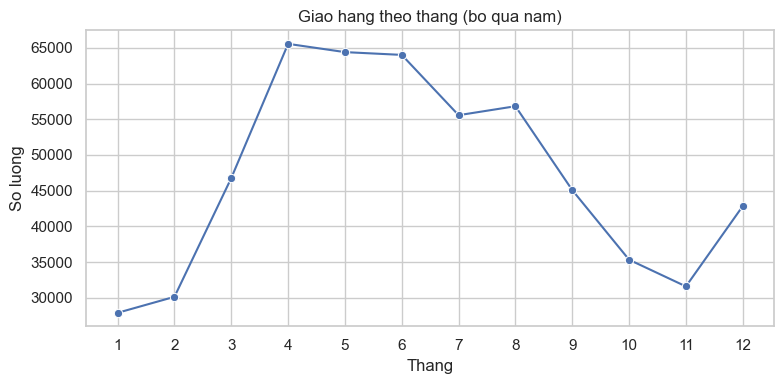

In [ ]:
# 3) So luong giao hang theo thang (bo qua nam)
ship_month = ship['ship_date'].dt.month.value_counts().sort_index()
month_labels = [str(m) for m in ship_month.index]
plt.figure(figsize=(8, 4))
sns.lineplot(x=month_labels, y=ship_month.values, marker='o')
plt.title('Giao hang theo thang (bo qua nam)')
plt.xlabel('Thang')
plt.ylabel('So luong')
plt.tight_layout()
plt.show()

**Nhận xét:** Tháng 4 cao nhất với 65,555 đơn; thấp nhất tháng 1 với 27,910 đơn.

## 2. Trả hàng (Returns)

**Chỉ số cần phân tích**:
- Return rate tổng thể (%)
- Lý do trả hàng phổ biến
- Return rate theo category sản phẩm

Return rate: 5.57%


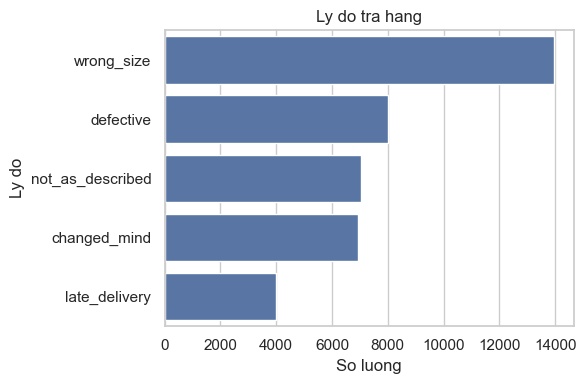

In [ ]:
# 1) Ly do tra hang
ret = returns.copy()
ret['return_date'] = pd.to_datetime(ret['return_date'])
reason_counts = ret['return_reason'].value_counts()

total_orders = orders['order_id'].nunique()
return_rate = ret['order_id'].nunique() / total_orders * 100
print(f"Return rate: {return_rate:.2f}%")

plt.figure(figsize=(6, 4))
sns.barplot(x=reason_counts.values, y=reason_counts.index, orient='h')
plt.title('Ly do tra hang')
plt.xlabel('So luong')
plt.ylabel('Ly do')
plt.tight_layout()
plt.show()

**Nhận xét:** Lý do trả hàng nhiều nhất là wrong_size (4,556 đơn), các lý do còn lại thấp hơn đáng kể. Công ty hoạt động ổn, tỷ lệ trả hàng chỉ có 5.57%. Nhưng, cần điều tra kỹ sao sai kích cỡ là lý do phổ biến nhất, có phải đến từ **sự thiếu đa dạng size**?

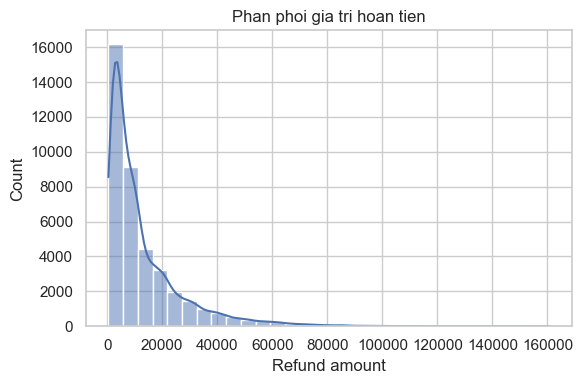

In [ ]:
# 2) Gia tri hoan tien
plt.figure(figsize=(6, 4))
sns.histplot(ret['refund_amount'], bins=30, kde=True)
plt.title('Phan phoi gia tri hoan tien')
plt.xlabel('Refund amount')
plt.tight_layout()
plt.show()

**Nhận xét:** Giá trị hoàn tiền trung vị 7,888.88; P90 = 30,910.35, cho thấy một nhóm nhỏ hoàn tiền rất cao. => Giá trị đơn hàng cao hay đây là nhóm khách hàng VIP chưa thỏa mãn với đơn hàng?

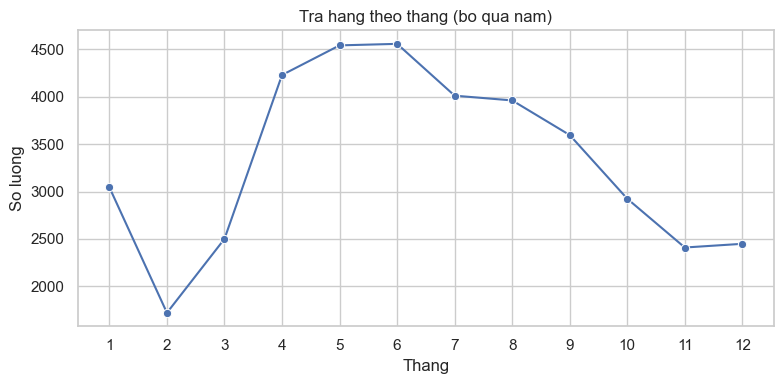

In [ ]:
# 3) Tra hang theo thang (bo qua nam)
ret_month = ret['return_date'].dt.month.value_counts().sort_index()
month_labels = [str(m) for m in ret_month.index]
plt.figure(figsize=(8, 4))
sns.lineplot(x=month_labels, y=ret_month.values, marker='o')
plt.title('Tra hang theo thang (bo qua nam)')
plt.xlabel('Thang')
plt.ylabel('So luong')
plt.tight_layout()
plt.show()

**Nhận xét:** Return rate 5.57% (tính trên tổng đơn). Trả hàng nhiều nhất tháng 6 (4,556), thấp nhất tháng 2 (1,722).

## 3. Đánh giá (Reviews)

**Chỉ số cần phân tích**:
- Phân phối điểm đánh giá (1-5 sao)
- Rating trung bình theo category
- Xu hướng rating theo thời gian

,count,pct
rating,,
1,5772,5.08
2,9095,8.01
3,17016,14.99
4,36412,32.07
5,45256,39.86


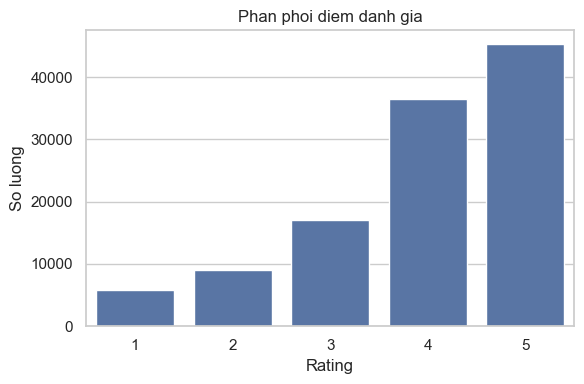

In [ ]:
# 1) Phan phoi rating
rev = reviews.copy()
rev['review_date'] = pd.to_datetime(rev['review_date'])

rating_counts = rev['rating'].value_counts().sort_index()
rating_pct = (rating_counts / rating_counts.sum() * 100).round(2)
display(pd.DataFrame({'count': rating_counts, 'pct': rating_pct}))

plt.figure(figsize=(6, 4))
sns.countplot(data=rev, x='rating')
plt.title('Phan phoi diem danh gia')
plt.xlabel('Rating')
plt.ylabel('So luong')
plt.tight_layout()
plt.show()

**Nhận xét:** 5 sao chiếm 39.86%, 4 sao 32.07%; điểm trung bình 3.94, phản ánh mức hài lòng khá tốt.

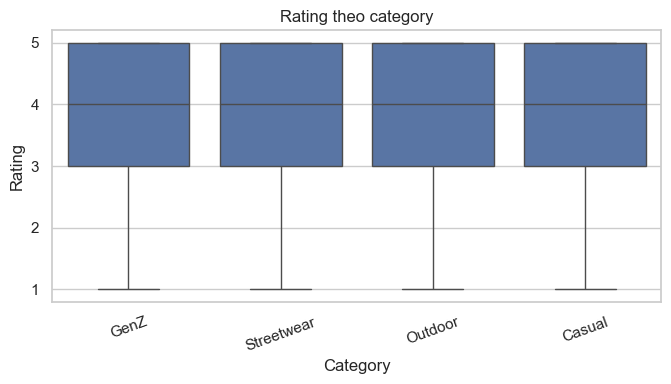

In [ ]:
# 2) Rating theo category
prod_cat = inventory[['product_id', 'category']].drop_duplicates()
rev_cat = rev.merge(prod_cat, on='product_id', how='left')

plt.figure(figsize=(7, 4))
sns.boxplot(data=rev_cat, x='category', y='rating')
plt.title('Rating theo category')
plt.xlabel('Category')
plt.ylabel('Rating')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Nhận xét:** Rating cao nhất ở Streetwear (3.94) và thấp nhất ở GenZ (3.92); chênh lệch nhỏ.

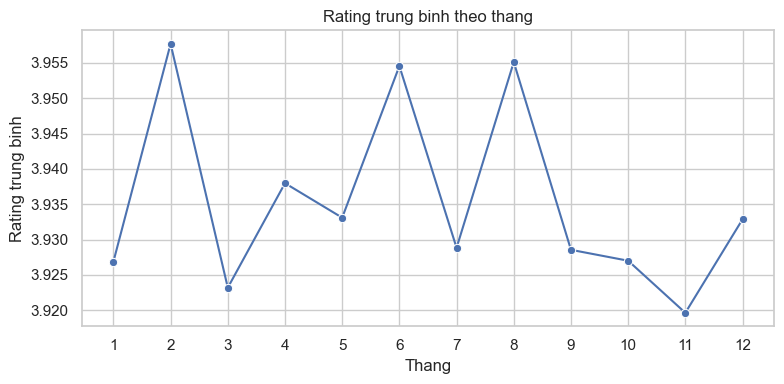

In [ ]:
# 3) Xu huong rating theo thang 
rev_month = rev.groupby(rev['review_date'].dt.month)['rating'].mean().sort_index()
month_labels = [str(m) for m in rev_month.index]
plt.figure(figsize=(8, 4))
sns.lineplot(x=month_labels, y=rev_month.values, marker='o')
plt.title('Rating trung binh theo thang')
plt.xlabel('Thang')
plt.ylabel('Rating trung binh')
plt.tight_layout()
plt.show()

**Nhận xét:** Rating trung bình cao nhất tháng 2 (3.96), thấp nhất tháng 11 (3.92).

## 4. Tồn kho (Inventory)

**Chỉ số cần phân tích**:
- Số lượng tồn kho theo sản phẩm/category
- Tỉ lệ out-of-stock
- Stock turnover rate

Stock median: 62
Stock P90: 532


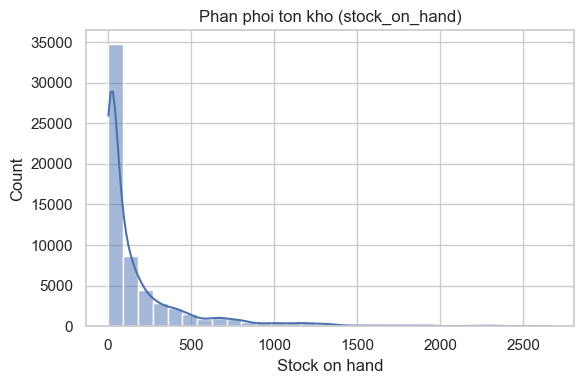

In [ ]:
# 1) Phan phoi ton kho
inv = inventory.copy()
stock_desc = inv['stock_on_hand'].describe(percentiles=[0.5, 0.9])
print(f"Stock median: {stock_desc['50%']:.0f}")
print(f"Stock P90: {stock_desc['90%']:.0f}")

plt.figure(figsize=(6, 4))
sns.histplot(inv['stock_on_hand'], bins=30, kde=True)
plt.title('Phan phoi ton kho (stock_on_hand)')
plt.xlabel('Stock on hand')
plt.tight_layout()
plt.show()

**Nhận xét:** Tồn kho trung vị 62, P90 = 532; phân bố lệch phải, một số sản phẩm tồn rất cao.

Stockout rate by category:


category
GenZ          0.682927
Outdoor       0.673492
Streetwear    0.673211
Casual        0.662004
Name: stockout_flag, dtype: float64

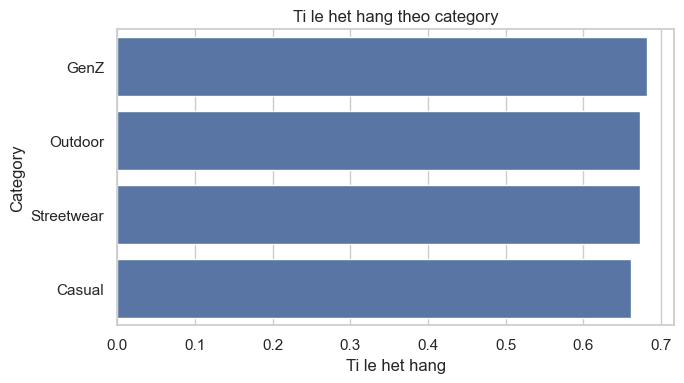

In [ ]:
# 2) Ti le het hang theo category
stockout_rate = inv.groupby('category')['stockout_flag'].mean().sort_values(ascending=False)
print('Stockout rate by category:')
display(stockout_rate)

plt.figure(figsize=(7, 4))
sns.barplot(x=stockout_rate.values, y=stockout_rate.index, orient='h')
plt.title('Ti le het hang theo category')
plt.xlabel('Ti le het hang')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

**Nhận xét:** Tỉ lệ hết hàng cao nhất ở GenZ (68.29%), thấp nhất ở Casual (66.20%); chênh lệch nhỏ nhưng vẫn cao. => GenZ có ít sản phẩm nhất, nhưng tỷ lệ cháy hàng lại nhanh nhất => Liệu công ty có đang bỏ quan sản phẩm tiềm năng là GenZ không?

Max month: 11 (avg 198.23)
Min month: 8 (avg 180.67)


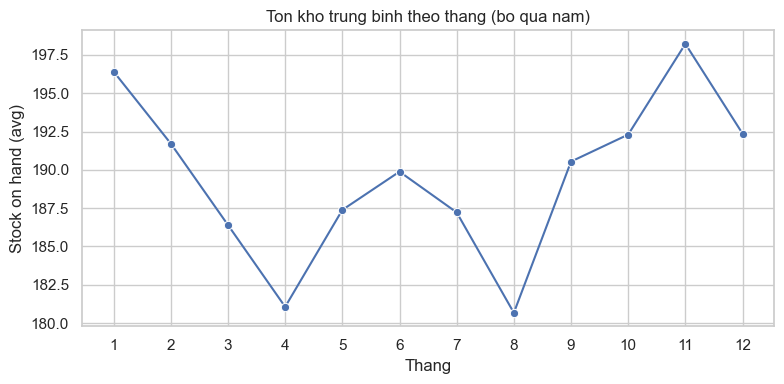

In [ ]:
# 3) Ton kho trung binh theo thang (bo qua nam)
inv_month = inv.groupby('month')['stock_on_hand'].mean().sort_index()
print(f"Max month: {inv_month.idxmax()} (avg {inv_month.max():.2f})")
print(f"Min month: {inv_month.idxmin()} (avg {inv_month.min():.2f})")
month_labels = [str(m) for m in inv_month.index]
plt.figure(figsize=(8, 4))
sns.lineplot(x=month_labels, y=inv_month.values, marker='o')
plt.title('Ton kho trung binh theo thang (bo qua nam)')
plt.xlabel('Thang')
plt.ylabel('Stock on hand (avg)')
plt.tight_layout()
plt.show()

**Nhận xét:** Tồn kho trung bình cao nhất tháng 11 (~198.23), thấp nhất tháng 8 (~180.67).